In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [5]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])

object
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']


In [6]:
print("Rows with empty TotalCharges:")
print(df[df['TotalCharges'] == ' '].shape[0])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

print("\nDtype after fix:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isnull().sum())

Rows with empty TotalCharges:
11

Dtype after fix: float64
Missing values: 0


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage of Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


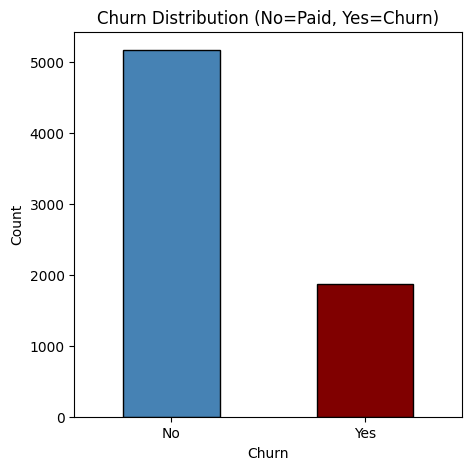

In [7]:
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\nPercentage of Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 5))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'maroon'], edgecolor='black')
plt.title('Churn Distribution (No=Paid, Yes=Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [8]:
df = df.drop('customerID', axis=1)

print("Categorical columns:")
print(df.select_dtypes(include=['object']).columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [9]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
print("\nData types after encoding:")
print(df.dtypes)

Encoding done!

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5634, 19)
Testing set size: (1409, 19)


In [11]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("Sample scaled values:", X_train_scaled[0])

Scaling done!
Sample scaled values: [-0.88435536 -0.39234163 -0.78370871  1.92343508 -0.28991572  0.34756544
 -0.97096199 -1.22920958  1.71711553 -0.89860055  1.43869957 -0.76609715
 -1.03832352  1.20061809  0.66708984 -1.21170846  1.46534332 -0.11011114
 -0.3374101 ]


In [13]:
xgb_model = XGBClassifier(n_estimators=100,
                          learning_rate=0.1,
                          max_depth=5,
                          random_state=42,
                          eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train_smote)
print("Model trained successfully!")

Model trained successfully!


In [14]:
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1036
           1       0.58      0.68      0.63       373

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409


ROC-AUC Score: 0.8448404359932511


In [15]:
xgb_model_tuned = XGBClassifier(n_estimators=200,
                                learning_rate=0.05,
                                max_depth=4,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                scale_pos_weight=2,
                                random_state=42,
                                eval_metric='logloss')

xgb_model_tuned.fit(X_train_scaled, y_train_smote)
print("Tuned model trained!")

Tuned model trained!


In [16]:
y_pred = xgb_model_tuned.predict(X_test_scaled)
y_prob = xgb_model_tuned.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.76      1409


ROC-AUC Score: 0.8456607699235045


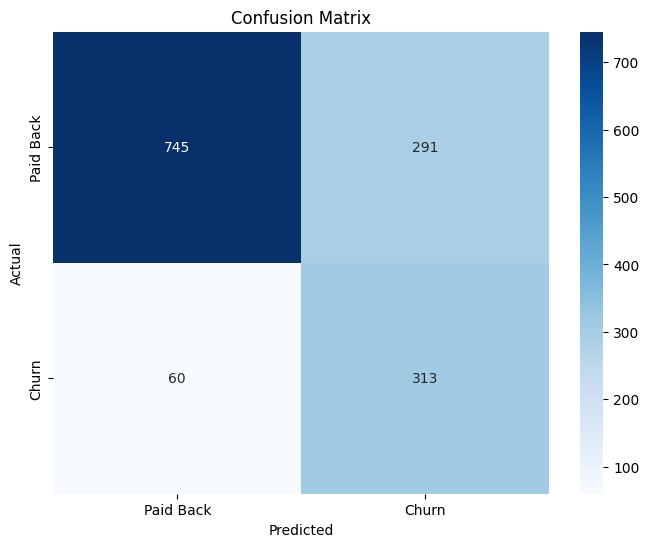

In [17]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid Back', 'Churn'],
            yticklabels=['Paid Back', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

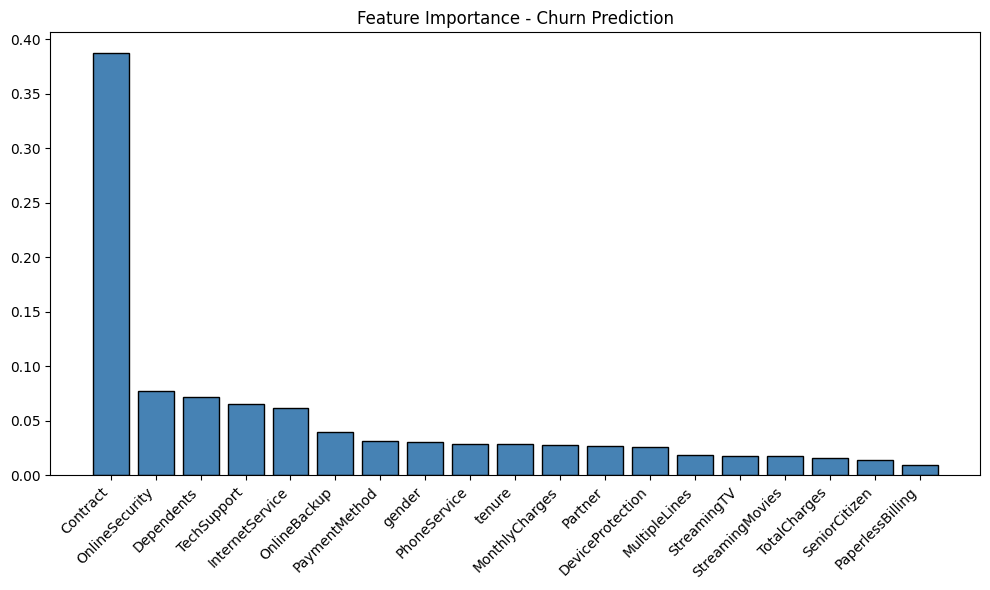

In [20]:
features_name = X.columns.tolist()
importances = xgb_model_tuned.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features_name)),
        importances[indices],
        color='steelblue',
        edgecolor='black')
plt.xticks(range(len(features_name)),
           [features_name[i] for i in indices],
           rotation=45, ha='right')
plt.title("Feature Importance - Churn Prediction")
plt.tight_layout()
plt.show()